# Imports

In [7]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-ncowan/input_data'

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from astropy.io import fits
import astropy.units as u
import astropy.constants as const

In [8]:
# STARSHIPS
from starships.planet_obs import Observations
import pipeline.reduction as red

# Injection-recovery functions

In [9]:
def plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig):
    plt.figure(figsize = (10, 4), dpi = 200)
    plt.subplot(211)
    plt.plot(wave_mod, mod_spec, label = 'Original model', linewidth = 0.5)
    plt.legend()
    plt.subplot(212)
    plt.plot(wave_mod, 1 - mod_spec_scaled, label = 'Scaled model')
    plt.legend()

    # if path_fig != '': plt.savefig(path_fig + '/scaled_model.pdf', bbox_inches = 'tight')

In [10]:
# Main function modified to fit the old STARSHIPS environment

def inj_rec(config_dict, p, obs, visit_name, wave_mod, mod_spec, scratch_dir = None, path_fig = '', debug = False):

    ''' Takes as input a model and a raw data file to inject the model into at a given RV.
    Assumed a list of t.fits files for the night have already been made (so, that split nights has been run)
    
    wave_mod and mod_spec: outputs of petitradtrans model -- mod_spec should be in units of transit depth (R_pl/R_star)**2
    '''

    # set save directory
    if scratch_dir == None:
        scratch_dir = Path(os.environ["SCRATCH"])
        scratch_dir /= Path(f'HRS_reductions/{config_dict["instrument"]}/{"".join(p.name.split())}/injected/{visit_name}/')
        scratch_dir.mkdir(parents=True, exist_ok=True)
    
    if path_fig == '':
        path_fig = scratch_dir / Path('Figures/')
        path_fig.mkdir(parents=True, exist_ok=True)
    
    # getting the exposures in and out of transit
    obs.calc_sequence(plot=False)
    in_transit = obs.iIn
    out_transit = obs.iOut

    # getting the lightcurve
    exp_times = obs.t
    lightcurve = obs.alpha

    # create the window function to scale the model 
    Wc = lightcurve / np.max(lightcurve)

    # getting velocities for correction after
    v_sys = p.RV_sys
    v_orb = obs.vrp
    berv = obs.berv

    # Scale the inputted model
    mod_spec_scaled = -(mod_spec - (p.R_pl / p.R_star)**2) * config_dict['scaling_factor']          #CHANGED TO -1 OF WHAT IT WAS

    # save a plot of the scaled model
    plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig)

    # shift the wavelength into the observer rest frame
    v_shift = v_orb[0].value + v_sys.value + config_dict['RV_inj'] + berv[0]
    wave_mod_shifted = wave_mod * (1 + v_shift / 299792.458)

    # setup a function to interpolate over the model
    interp_wavelength = interp1d(wave_mod_shifted, mod_spec_scaled, kind='cubic', bounds_error=False, fill_value=0.)

    # get list of all exposures
    with open(str(config_dict['obs_dir'])+'/'+'list_tcorr.txt') as f:
        exp_list = f.readlines()


    # Initialize lists to store data
    wavelengths = []
    counts = []

    for i, exp in enumerate(exp_list):
        
        # Shift the model wavelength into the observer rest frame for this exposure
        v_shift = v_orb[i].value + v_sys.value + config_dict['RV_inj'] + berv[i]
        wave_mod_shifted = wave_mod * (1 + v_shift / 299792.458)

        # setup a function to interpolate over the model
        interp_wavelength = interp1d(wave_mod_shifted, mod_spec_scaled, kind='cubic', bounds_error=False, fill_value=0.)
        
        if debug:
            # plot each exposure
            plt.figure(figsize = (8, 3), dpi = 200)
        
        # load the exposure
        with fits.open(str(config_dict['obs_dir'])+'/'+exp.strip(), memmap=False) as hdul:

            count = hdul[1].data  # copy of the flux data
            wv = hdul[2].data / 1000
            
            new_count = count.copy()  # create a copy to modify

            # iterate over the wavelength bits
            for w in range(len(wv)):

                if debug:
                    # plot original 
                    if w == 0: plt.plot(wv[w], count[w], label='Original', zorder=1)
                    else: plt.plot(wv[w], count[w], zorder=1)

                # interpolate the model to the wavelength, and scale by the lightcurve
                mod_interp = 1 - interp_wavelength(wv[w]) * Wc[i]

                # multiply the count by the model in that range
                new_count[w] = count[w] * mod_interp

                if debug:
                    # plot new
                    if w == 0: plt.plot(wv[w], new_count[w], label='Injected', color = 'blue', zorder=0)
                    else: plt.plot(wv[w], new_count[w], color = 'blue', zorder=0)
            
            # Assign the modified data back to the HDU
            hdul[1].data = new_count

            # Save to new fits file with same name, in new folder
            hdul.writeto(str(scratch_dir / exp.strip()), overwrite=True)

            # Append wavelengths and counts for this exposure to the lists
            wavelengths.append(wv)
            counts.append(hdul[1].data)

            if debug:
                plt.title(f'Exposure {exp.strip()}')
                plt.legend()
                plt.savefig(str(scratch_dir / 'wavelength_time_plot.pdf'))
                # plt.show()

    # copy e2ds files into scratch so we can use it as a new obs_dir
    # get list of all exposures
    with open(str(config_dict['obs_dir'])+'/'+f'list_e2ds.txt') as f:
        e2ds_list = f.readlines()

    for i, e2ds in enumerate(e2ds_list):
        os.system(f'cp {config_dict["obs_dir"]}/{e2ds.strip()} {scratch_dir}')

    # copy the e2ds and tcorr lists into the scratch
    os.system(f'cp {config_dict["obs_dir"]}/list_tcorr.txt {scratch_dir}')
    os.system(f'cp {config_dict["obs_dir"]}/list_e2ds.txt {scratch_dir}')


# Setup

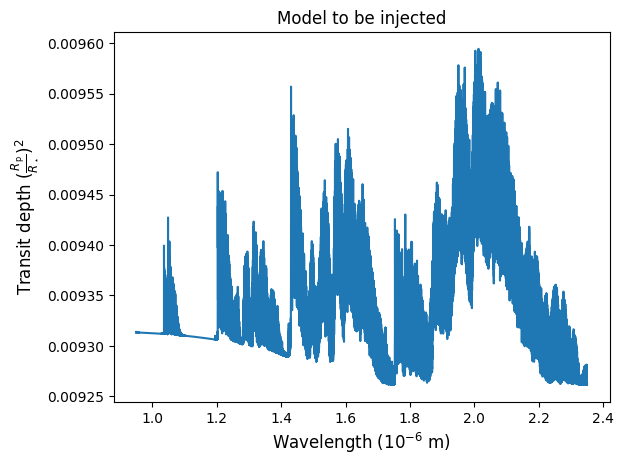

In [4]:
# INFORMATION
pl_name = "TRAPPIST-1 b"
instrument = "SPIRou_with_persi"

scaling = 100.0  # scaling factor to multiply the model (transit depth) with
RV_inj = -75  # RV where to inject the signal


# PARAMETERS OF THE PLANET
ap     = 0.01150*u.au       # semi-major axis of planet
R_star = 0.121*u.R_sun      # radius of star
R_pl   = 1.127*u.R_earth    # radius of planet
M_star = 0.089*const.M_sun  # mass of star
e      = 0                  # eccentricity
w      = 4.712389*u.rad     # argument of periapsis (equal to 270 degrees)


# MODEL TO INJECT
model_directory = "/home/mathisb/Github/HRS_models/"
model_filename = "prt_model_TRAPPIST-1b_CO2_v03.npz"  # npz file

#----------------------------------------------------------------#

model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

# Convert model from Earth radii to transit depth
R_earth = const.R_earth.to(u.R_earth)
mod_spec = (model_spec*u.R_earth * (R_pl/R_earth))**2 / (R_star.to(u.R_earth))**2

# Plot it
plt.plot(wave_mod, mod_spec)

plt.xlabel('Wavelength ($10^{-6}$ m)', fontsize=12)
plt.ylabel(r'Transit depth $(\frac{R_{\rm p}}{R_{\rm \star}})^2$', fontsize=12)
plt.title('Model to be injected')
plt.show()

In [5]:
# SOME IMPORTANT DICTIONARIES

# Lists of data files
list_filenames = {'list_e2ds': 'list_e2ds.txt',
                  'list_tcorr': 'list_tcorr.txt'}

# Mid-transit time (BJD) of each TRAPPIST-1 b visit (calculated from Agol et al. 2021)
mid_tr_dict = {"2019-06-14": 2458649.07123219 * u.d,
               "2019-09-25": 2458751.81121859 * u.d,
               "2020-05-31": 2459001.10675595 * u.d,
               "2020-08-04": 2459066.07480784 * u.d,
               "2020-09-08": 2459100.82490157 * u.d,
               "2020-09-20": 2459112.91190288 * u.d,
               "2020-09-26": 2459118.95517189 * u.d,
               "2020-09-29": 2459121.97749932 * u.d,
               "2021-10-21": 2459508.7625026763 * u.d,
               "2021-10-24": 2459511.7847065893 * u.d,
               "2021-10-27": 2459514.8059848337 * u.d,
                }

# Data required for the injection
config_dict = {
                "instrument" : instrument,
                'scaling_factor' : scaling,
                'RV_inj' : RV_inj,
              }

# Run the injection

### One night

INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2459121.97749932 d
INFO:starships.planet_obs:It became [2459121.97749932] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.pl

([4.307670635500154, 4.569041542362253, 5.159650805313745, 4.513453876012333, 4.454151488630733, 4.299213684381538, 4.101907813512767, 4.191908176399508, 4.000427042961204, 3.5906681772569082, 4.364606541097676, 4.090753300875333, 4.454700111515313, 3.915664137755881, 4.321435654254567, 3.7815557310320127],)
[2459121.97749932] d
Transmission


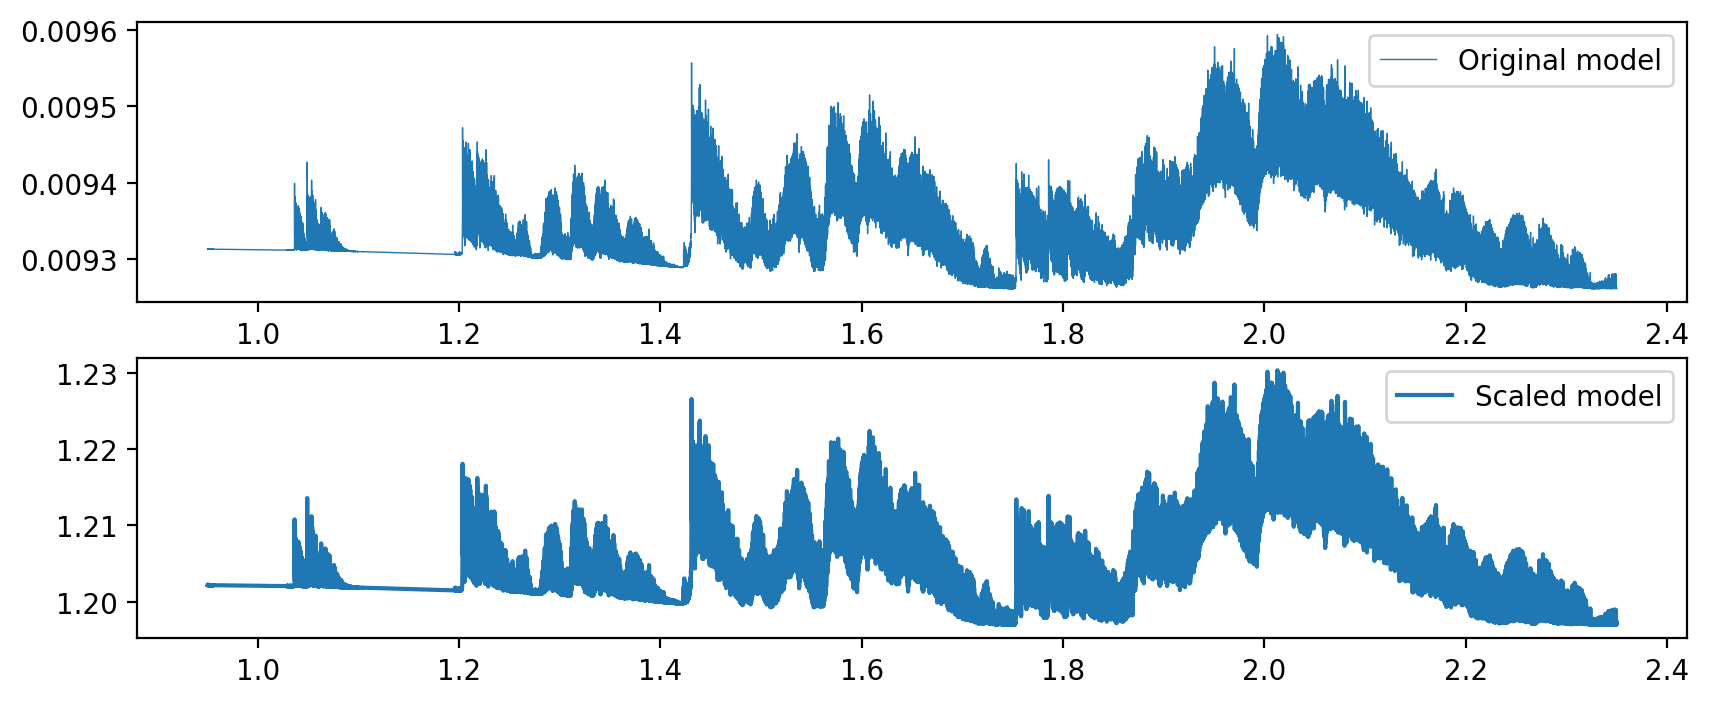

In [13]:
visit_name = '2020-09-29'  # name of the night

#---------------------------------------------#

# Directory where the data is
obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"  # directory where the data is

config_dict['obs_dir'] = obs_dir

mid_tr = mid_tr_dict[visit_name]

# Create obs and planet objects
obs = Observations(name=pl_name, 
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                'excent': e,
                                'w': w})

obs.fetch_data(obs_dir, **list_filenames, CADC=True)
p = obs.planet

# Inject
inj_rec(config_dict, p, obs, visit_name, wave_mod, mod_spec, scratch_dir=None, path_fig='', debug=False)

### Multiple nights

INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2458649.07123219 d
INFO:starships.planet_obs:It became [2458649.07123219] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.pl

([3.5718153925122467, 2.875254069317059, 2.7398864331346773, 3.3628220675613876, 2.521954861742761, 2.542373026915956, 2.82423567806246, 2.3078392649545205, 2.186763395545284, 2.5027243238877714, 1.847302315620529, 2.426588180742971, 2.8257769539693185, 2.7657196539361353],)
[2458649.07123219] d
Transmission


INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2458751.81121859 d
INFO:starships.planet_obs:It became [2458751.81121859] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.pl

([7.02494586538764, 5.896407583110947, 5.627887702657711, 4.781274912172397, 5.404977891090587, 4.129552422235754, 4.125206625988665, 4.322540302526255, 4.531308337659035, 4.610277824046194, 3.7688157412468044, 4.953284032261623, 4.2122208304436946, 4.26795831487626],)
[2458751.81121859] d
Transmission


INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2459001.10675595 d
INFO:starships.planet_obs:It became [2459001.10675595] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.pl

...

([5.429777052494881, 4.92232741574094, 4.111218647467623, 4.314768580695611, 4.0314506393634035, 4.407349056017631, 4.151146948677209, 4.137862702724522, 3.4477811222246797, 3.677550823513407, 4.249019494613217, 4.4021423623662725, 3.80013731740874, 4.007313079008623, 3.8884121629007673, 4.0476883454962245],)
[2459508.76250268] d
Transmission


INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2459511.7847065893 d
INFO:starships.planet_obs:It became [2459511.78470659] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.

([5.288093411801997, 5.501519467826659, 5.452711793548092, 4.760005269202172, 4.677769869355209, 4.883728023135374, 4.7829845925603225, 4.919643587068462, 4.739452532310887, 4.802733520307832, 5.240272740983751, 5.240735565607319, 4.657069709098198, 5.031921756696264, 5.817672846735637, 5.265733152859419],)
[2459511.78470659] d
Transmission


INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2459514.8059848337 d
INFO:starships.planet_obs:It became [2459514.80598483] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.

([5.355119822157192, 5.308441679751687, 5.793575003697012, 5.571892870995753, 5.435547212078952, 5.15668682245618, 4.6609614250049365, 5.147048236325375, 4.077331294552507, 5.07793665572799, 5.283074752609919, 4.862096422337465, 4.705449936604475, 4.463849619189252, 4.439980924497547, 4.379494375958981],)
[2459514.80598483] d
Transmission


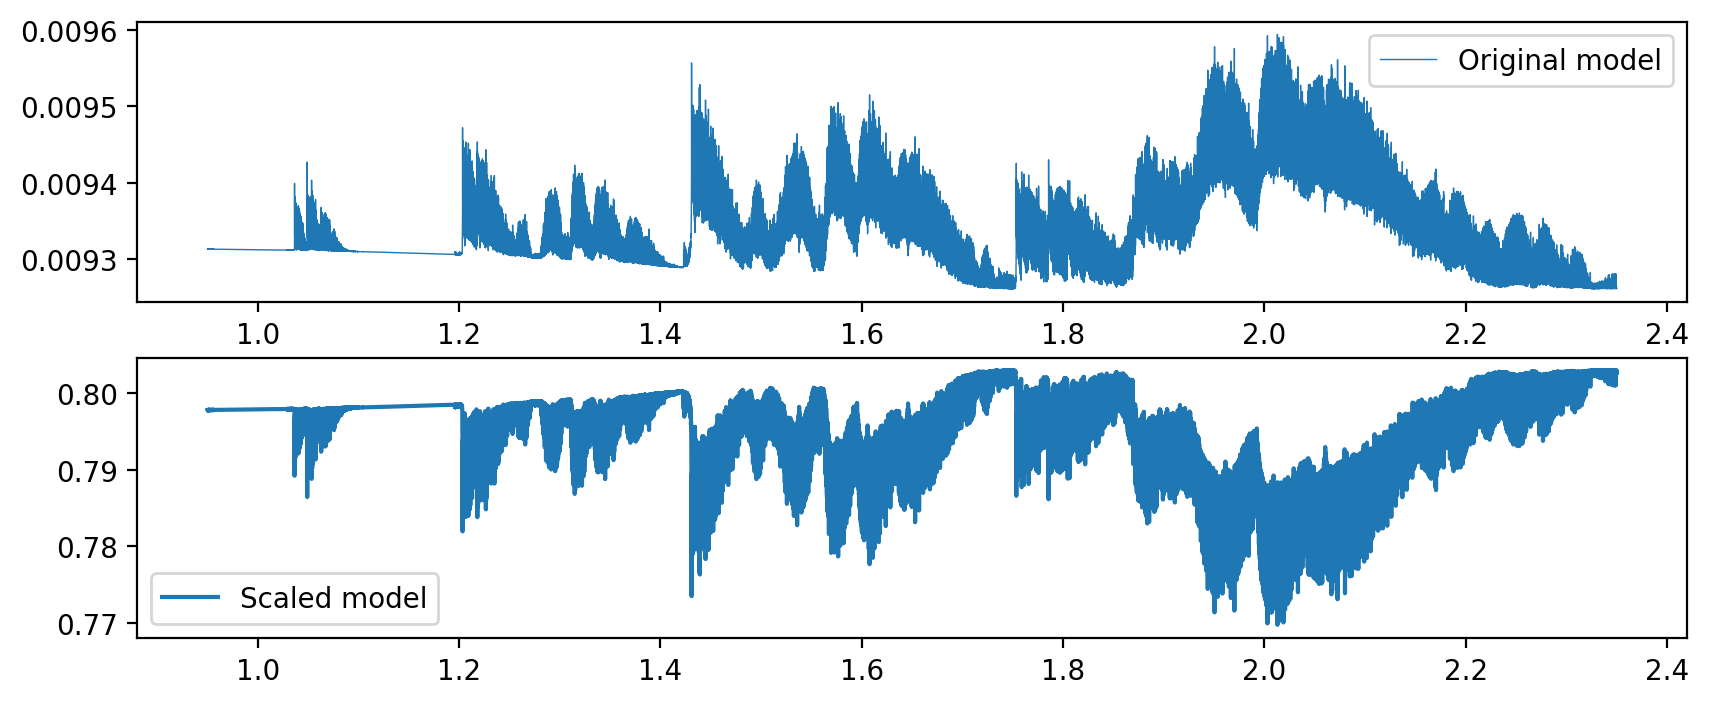

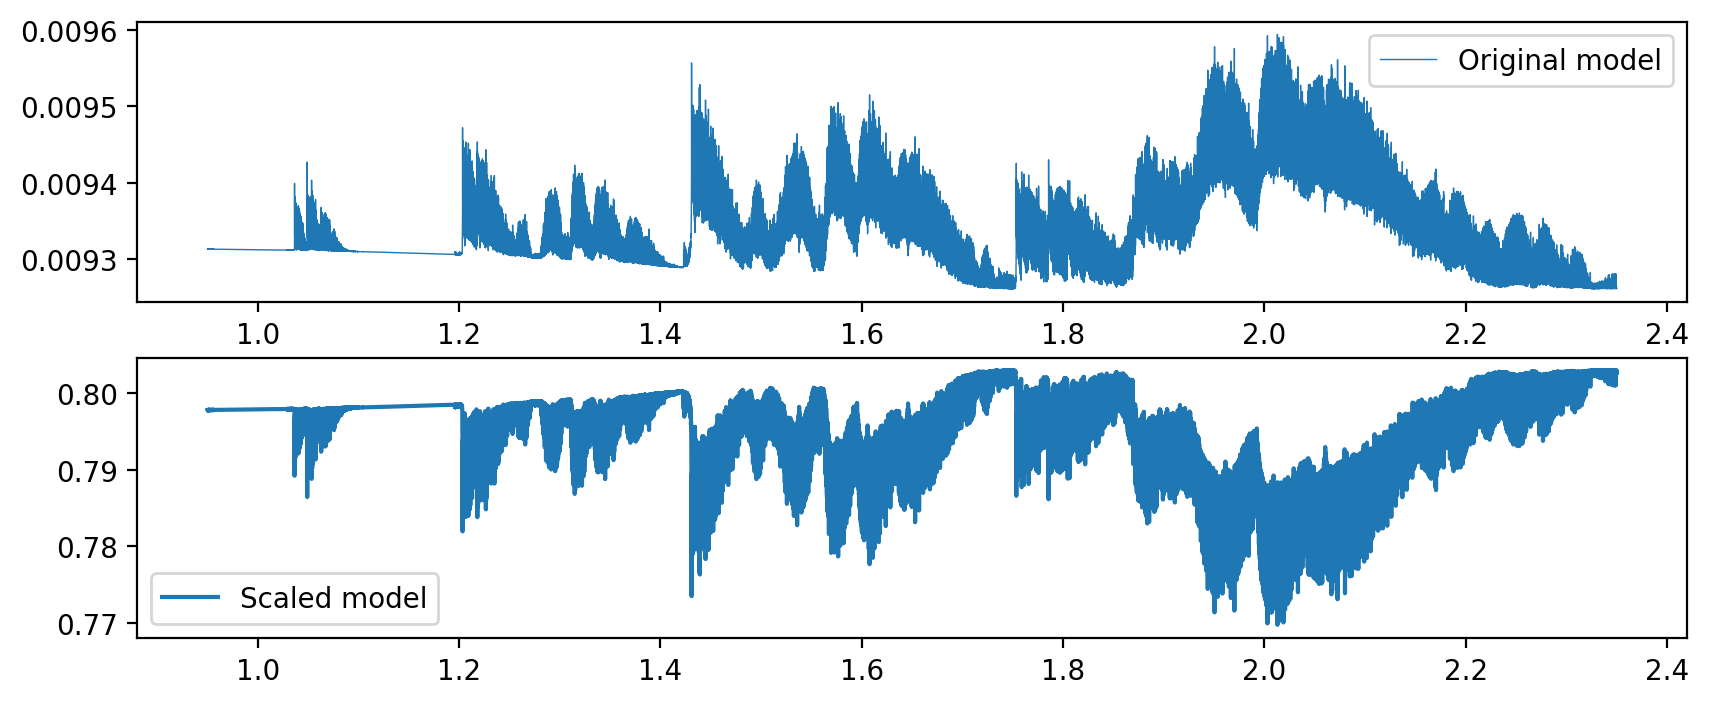

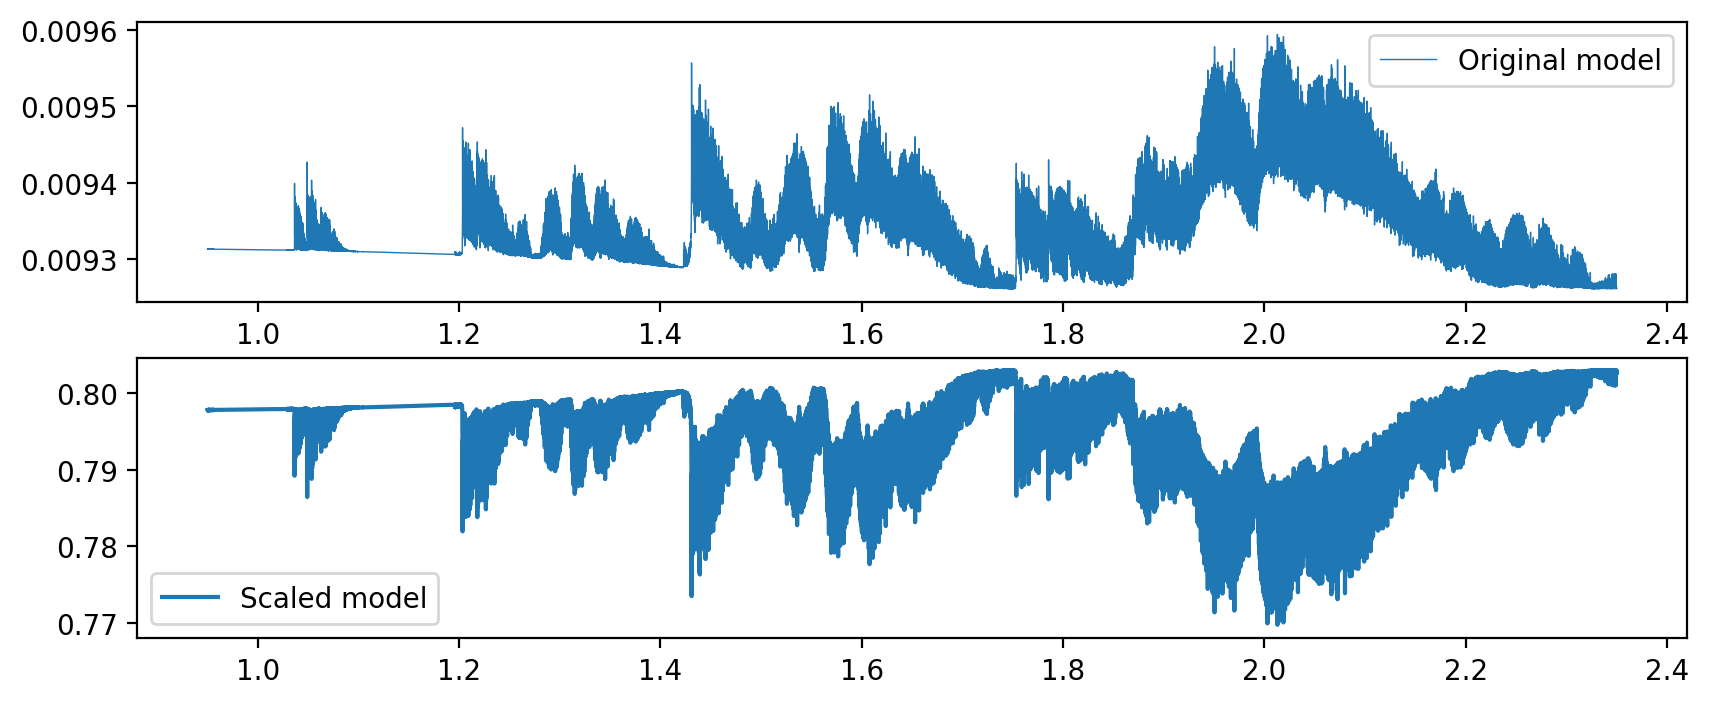

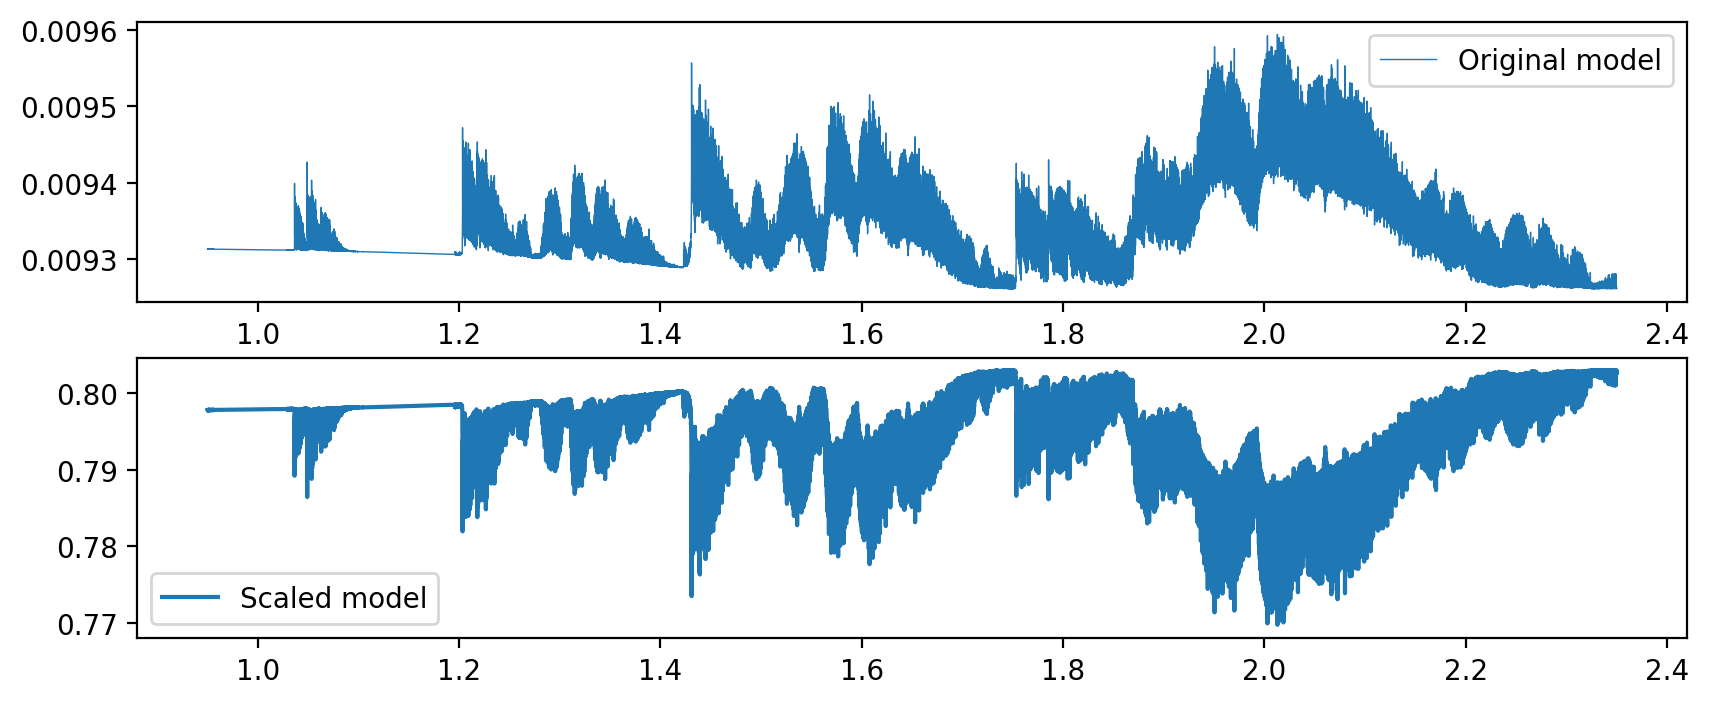

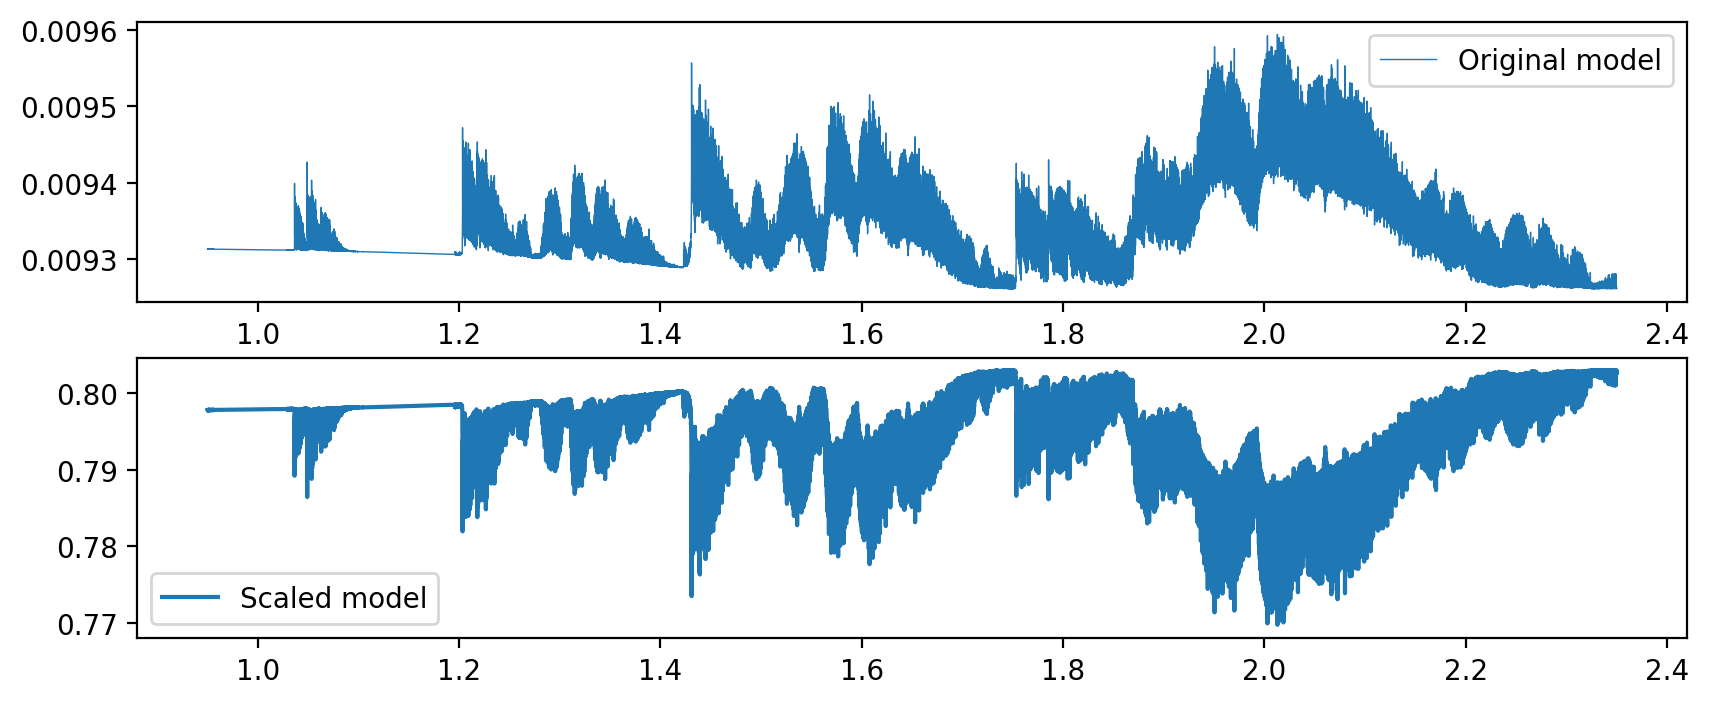

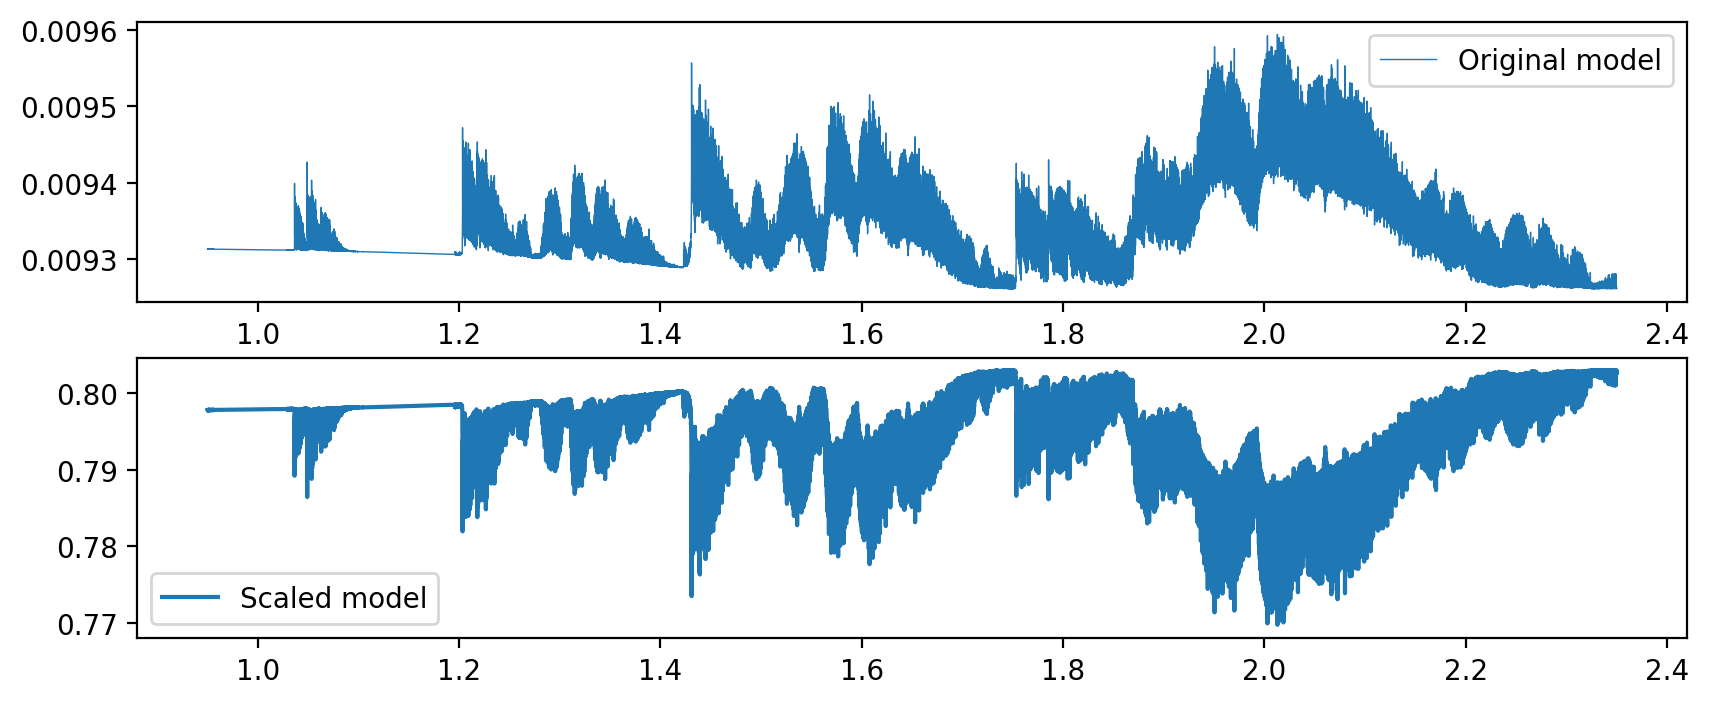

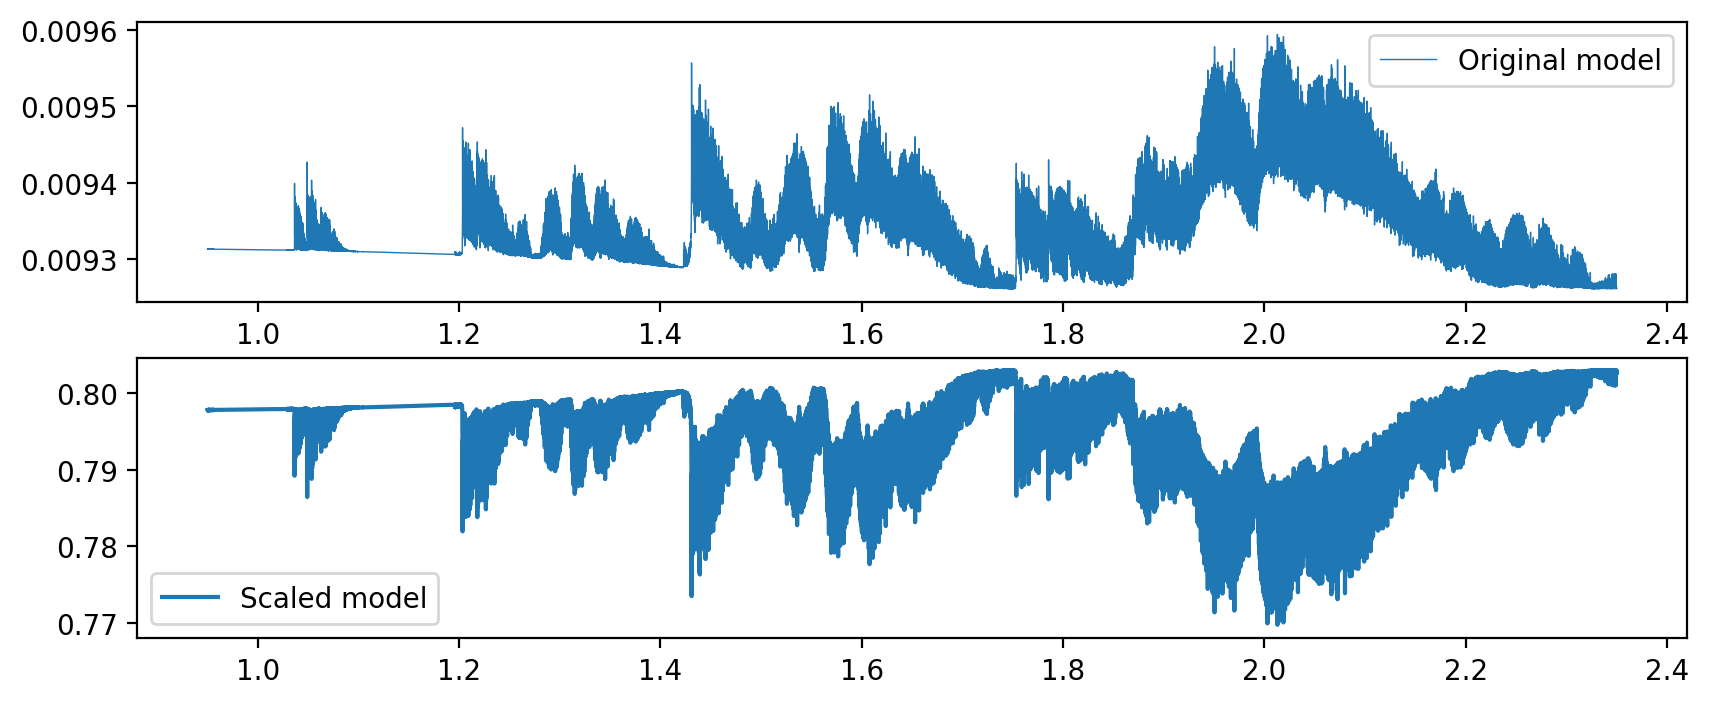

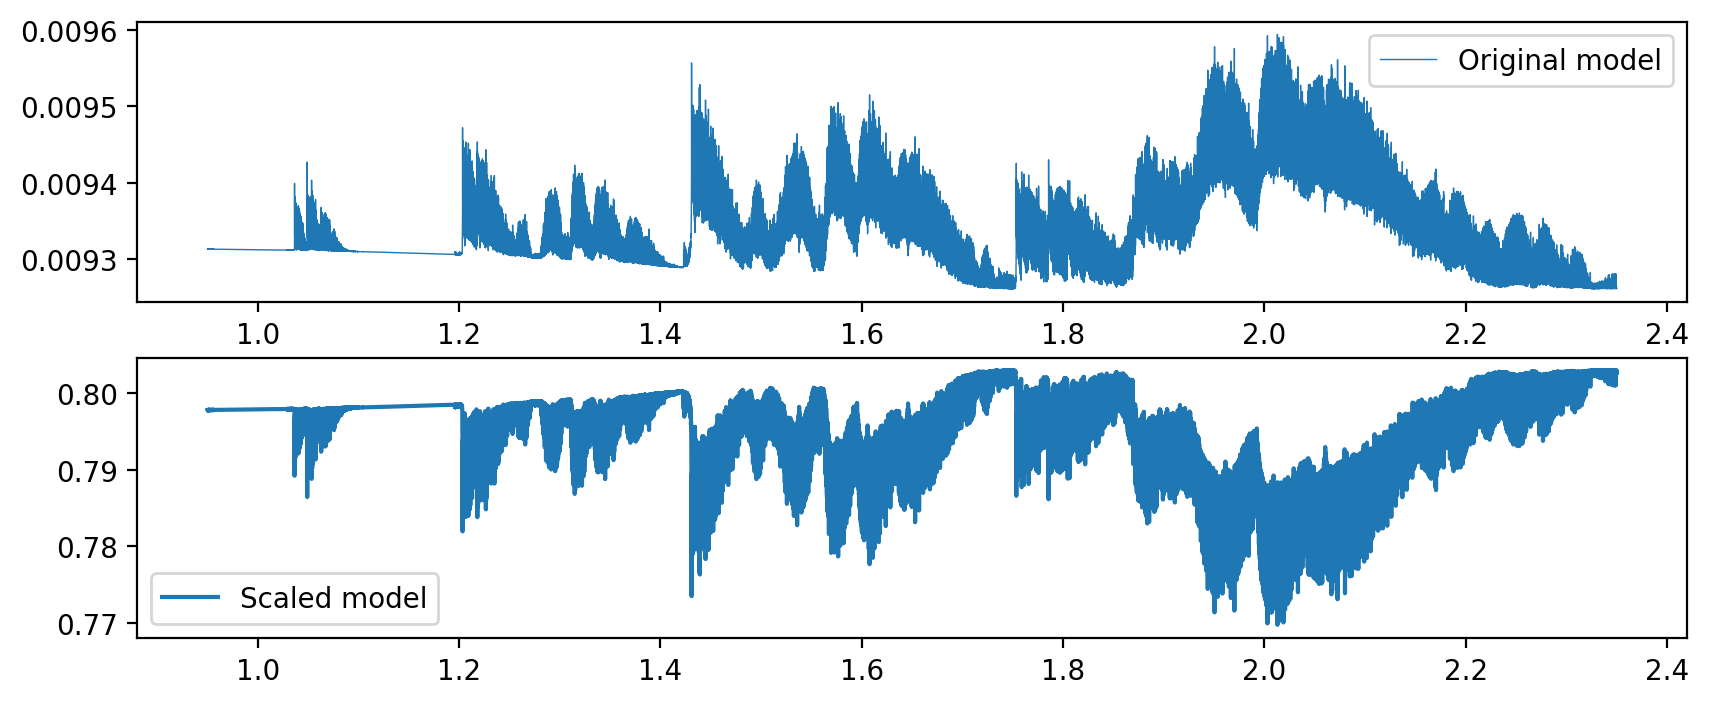

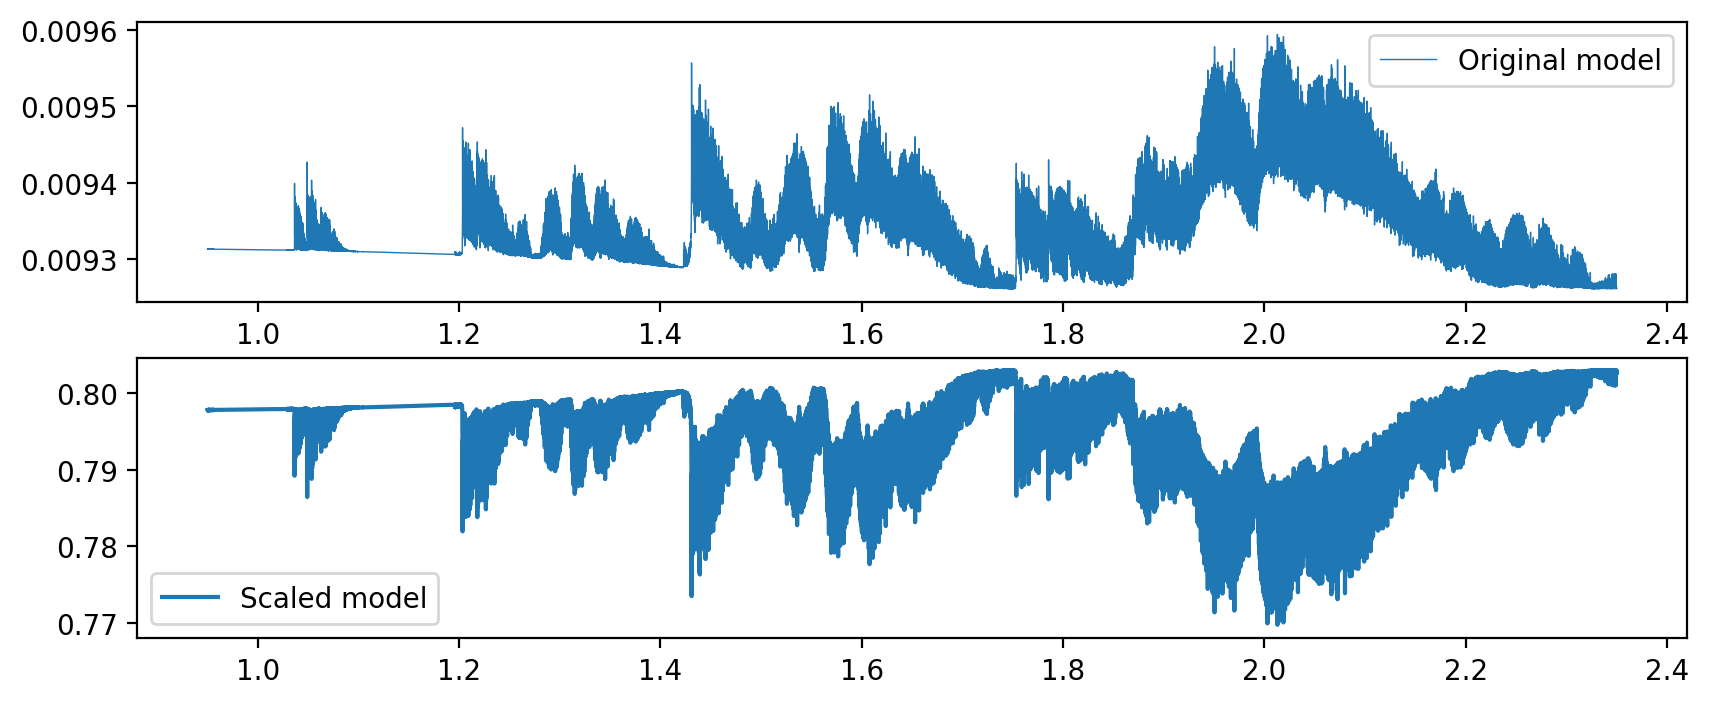

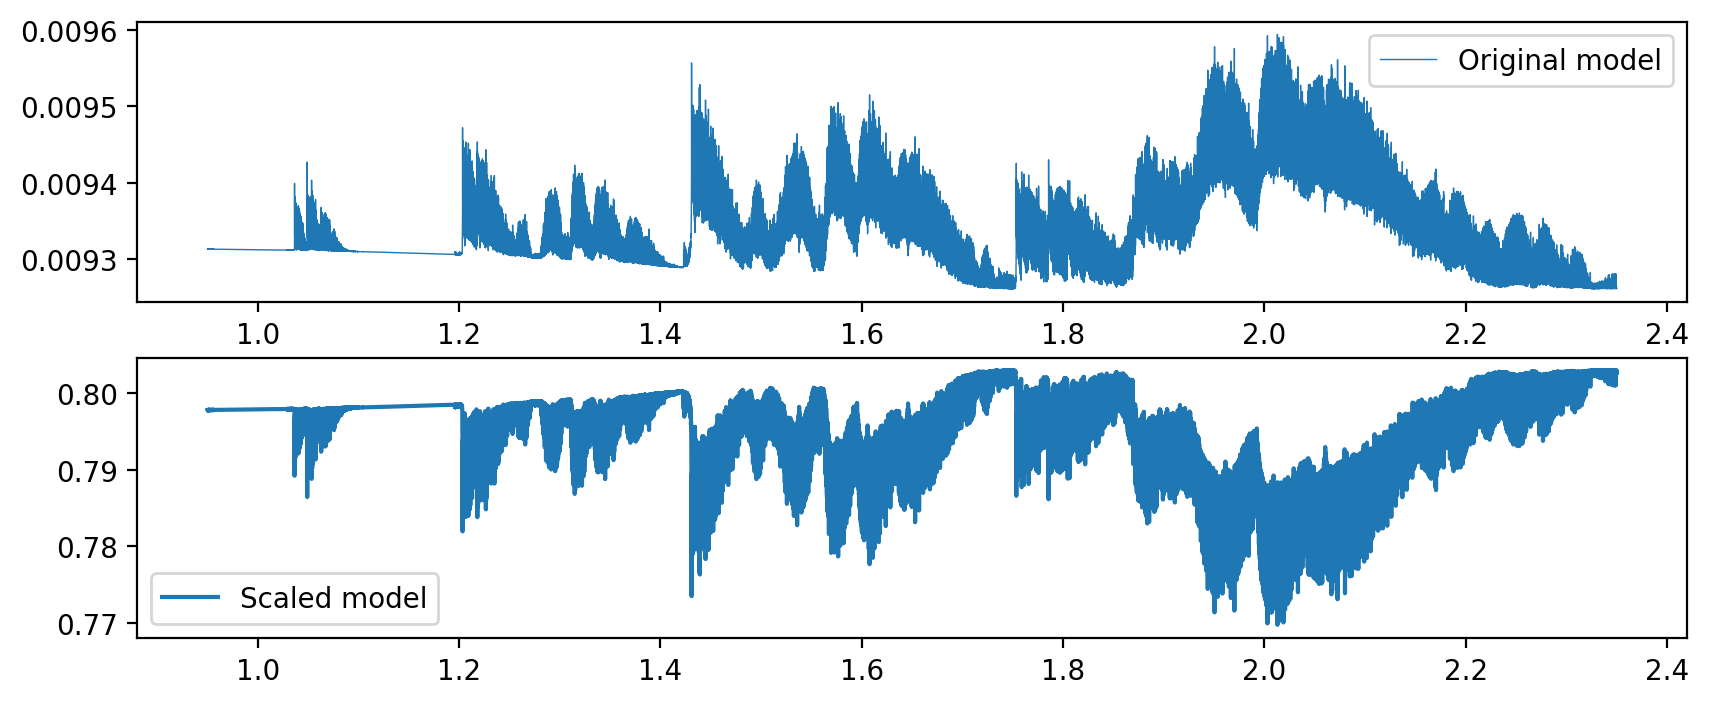

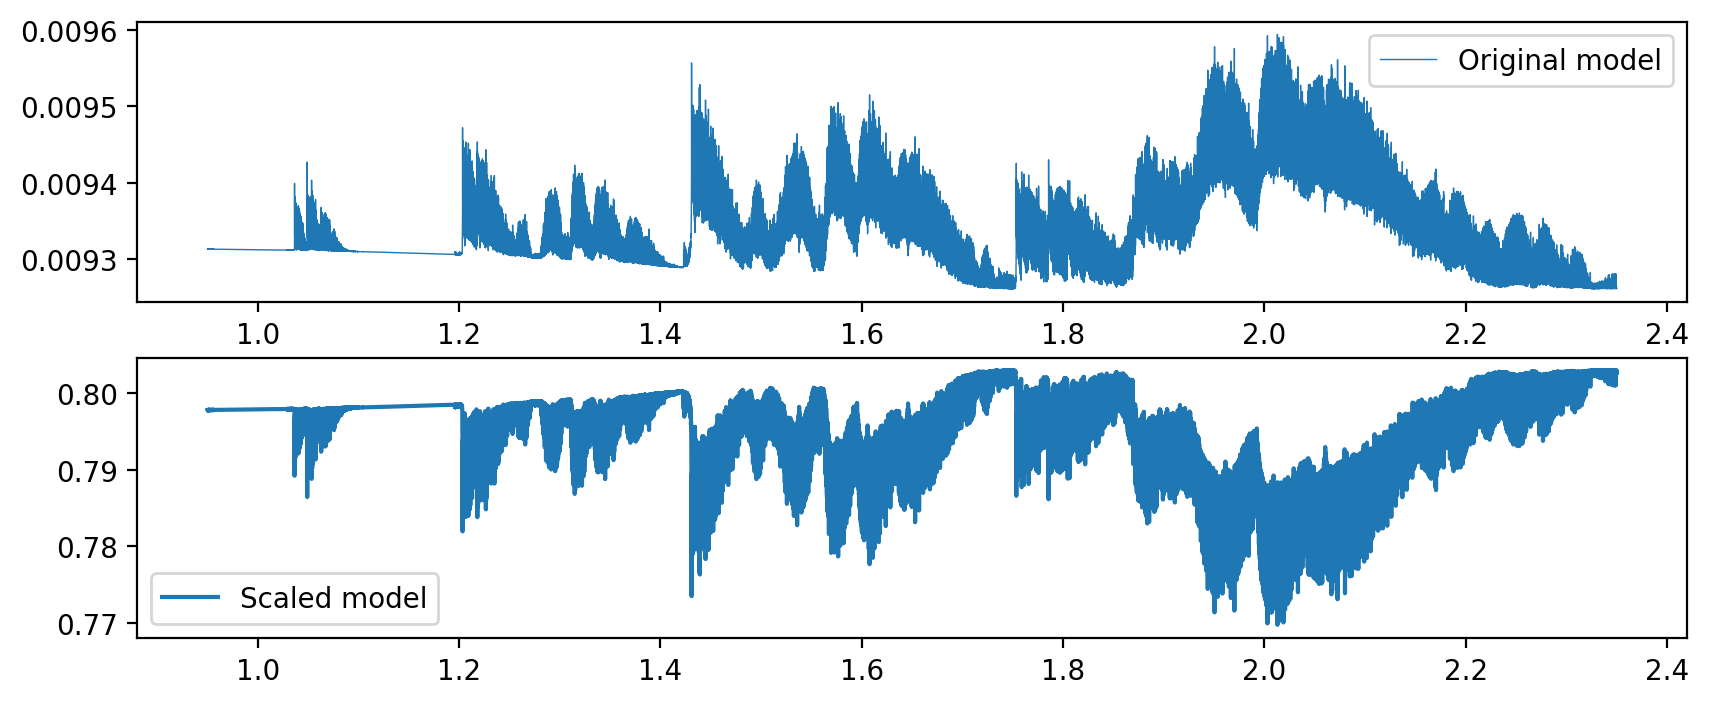

In [12]:
# Where to inject a signal
nightlist = ["2019-06-14",
               "2019-09-25",
               "2020-05-31",
               "2020-08-04",
               "2020-09-08",
               "2020-09-20",
               "2020-09-26",
               "2020-09-29",
               "2021-10-21",
               "2021-10-24",
               "2021-10-27"
               ]

#------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print all the log information

for night in nightlist:
    visit_name = night
    
    # Directory where the data is
    obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"
    config_dict['obs_dir'] = obs_dir
    
    mid_tr = mid_tr_dict[visit_name]
    
    # Create obs and planet objects
    obs = Observations(name=pl_name, 
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                'excent': e,
                                'w': w})

    obs.fetch_data(obs_dir, **list_filenames, CADC=True)
    p = obs.planet
    
    # Inject
    inj_rec(config_dict, p, obs, visit_name, wave_mod, mod_spec, scratch_dir=None, path_fig='', debug=False)


pl_obs.log.setLevel("INFO")  # go back to normal log printing